# Compare beam trackers: `SimplePXRLoader` vs `PXRLoader`

Point this at a folder of `.fits` files, tweak the parameters, and process the
same data with **both** trackers so you can see where they agree and disagree.

- **simple** — the new median-filter + local-argmax tracker
  (`SimplePXRLoader`), with a per-scan seed and a re-seed at the `sam_z` move.
- **current** — the existing SNR-gated tracker (`PXRLoader.process`).

Both use the *same* reduction config; the only difference is how the beam
centre is found. Run the cells top to bottom.

## 1. Parameters — edit these

In [1]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pxr_reduce.config import ReductionConfig
from pxr_reduce.core import PXRLoader
from pxr_reduce.simple_track import SimplePXRLoader

# Show pxr-reduce INFO logs (frame shape, per-stage timing summary) inline.
logging.basicConfig(level=logging.WARNING, format="%(message)s")
logging.getLogger("pxr_reduce").setLevel(logging.INFO)

# ---- Point this at your data -------------------------------------------
DATA_PATH = r"C:\Users\TJFerron\Documents\Temp_Data\Wenkai_Z\XRR_TEST\short_scan2"   # folder containing .fits files
FILE_GLOB = "*.fits"

# ---- Simple-tracker knobs ----------------------------------------------
SEARCH_RADIUS = 45    # px the beam may drift between sequential frames
FILTER_SIZE   = 3     # median-filter kernel used to FIND the beam

# ---- Shared reduction config (both trackers use these) -----------------
CONFIG_KW = dict(
    detector="default",
    trim_x=20,
    trim_y=20,
    roi_height=40,
    roi_width=40,
    dark_pix_offset=50,
    dezinger=True,
)

## 2. Find the files

In [2]:
files = sorted(Path(DATA_PATH).glob(FILE_GLOB))
print(f"Found {len(files)} file(s) in {DATA_PATH}")
assert files, "No FITS files found - check DATA_PATH and FILE_GLOB."

Found 401 file(s) in C:\Users\TJFerron\Documents\Temp_Data\Wenkai_Z\XRR_TEST\short_scan2


## 3. Process with the **simple** tracker

`search_radius` and `filter_size` override the config defaults here.

A live progress bar shows the current **scan**, frame **idx**, **beam** position
and **step** (`seed` vs `track`). Watch it to see the per-frame rate and ETA:

- If it looks stuck, the logged `First frame loaded: trimmed shape ...` line
  tells you how large each frame is (big frames = slow median filter).
- If it stops advancing on one index, that frame is the one hanging.
- The end-of-run line breaks time down by stage
  (`load / locate / dezinger / integrate`) so you can see what dominates.
- Set `verbose=True` to log those timings for **every** frame.

In [3]:
simple = SimplePXRLoader(files, ReductionConfig(**CONFIG_KW))
simple.process(
    search_radius=SEARCH_RADIUS,
    filter_size=FILTER_SIZE,
    progress=True,   # live per-frame bar
    verbose=False,   # set True for per-frame stage timings
)
simple.data[["fits_index", "scan", "sam_th", "beam_spot", "counts_refl"]].head()

Loading 401 file(s) — reading headers...


Loading FITS headers:   0%|          | 0/401 [00:00<?, ?file/s]

sam_th offset not given; assuming theta-2theta geometry -> offset determined to be -0.2775 deg
Loaded 401 frames for sample 'B1A1_XRR_P100_17344_'
Simple tracker starting: 401 frame(s) in 1 scan(s), search radius 45 px, median filter 3.


Simple track:   0%|          | 0/401 [00:00<?, ?frame/s]

First frame: trimmed shape (1960, 2160), dtype float64. Direct-beam/seed frames filter the full frame; tracked frames filter only a 351x351 region.
Simple tracker done: 401 frame(s) in 23.7s (load 10.7s, median 11.3s, locate 0.1s, clean 1.5s, integrate 0.1s).


,fits_index,scan,sam_th,beam_spot,counts_refl
0,0,0,-0.2775,"(1125, 792)",795756.139387
1,1,0,-0.2775,"(1126, 792)",788328.427939
2,2,0,-0.2775,"(1126, 792)",830691.846516
3,3,0,-0.2775,"(1126, 792)",768179.967898
4,4,0,-0.2775,"(1126, 792)",802204.200435


## 4. Process with the **current** tracker

In [4]:
current = PXRLoader(files, ReductionConfig(**CONFIG_KW))
current.process()
current.data[["fits_index", "scan", "sam_th", "beam_spot", "beam_found", "beam_snr"]].head()

Loading 401 file(s) — reading headers...


Loading FITS headers:   0%|          | 0/401 [00:00<?, ?file/s]

sam_th offset not given; assuming theta-2theta geometry -> offset determined to be -0.2775 deg
Loaded 401 frames for sample 'B1A1_XRR_P100_17344_'
Building integration mask from 134 frame(s)


Building mask:   0%|          | 0/134 [00:00<?, ?it/s]

Tracking beam (search radius 45 px) and integrating 401 frame(s)...


Scan 0:   0%|          | 0/391 [00:00<?, ?it/s]

,fits_index,scan,sam_th,beam_spot,beam_found,beam_snr
0,0,0,-0.2775,"(1126, 792)",True,3606.309379
1,1,0,-0.2775,"(1127, 792)",True,4245.469670
2,2,0,-0.2775,"(1127, 792)",True,4379.356086
3,3,0,-0.2775,"(1127, 792)",True,3943.522640
4,4,0,-0.2775,"(1127, 792)",True,4439.273349


## 5. Compare beam positions

`dist` is the pixel distance between the two trackers' beam centres for each
frame. Large values are the frames where they disagree.

In [5]:
def beam_frame(loader, label):
    """Extract per-frame (y, x) beam positions as a tidy DataFrame."""
    d = loader.data
    return pd.DataFrame({
        "fits_index": d["fits_index"].to_numpy(),
        "scan": d["scan"].to_numpy(),
        "sam_th": d["sam_th"].to_numpy(),
        f"y_{label}": [bs[0] for bs in d["beam_spot"]],
        f"x_{label}": [bs[1] for bs in d["beam_spot"]],
    })

cmp = beam_frame(simple, "simple").merge(
    beam_frame(current, "current")[["fits_index", "y_current", "x_current"]],
    on="fits_index",
)
cmp["dy"] = cmp["y_simple"] - cmp["y_current"]
cmp["dx"] = cmp["x_simple"] - cmp["x_current"]
cmp["dist"] = np.hypot(cmp["dy"], cmp["dx"])
cmp

,fits_index,scan,sam_th,y_simple,x_simple,y_current,x_current,dy,dx,dist
0,0,0,-0.2775,1125,792,1126,792,-1,0,1.000000
1,1,0,-0.2775,1126,792,1127,792,-1,0,1.000000
2,2,0,-0.2775,1126,792,1127,792,-1,0,1.000000
3,3,0,-0.2775,1126,792,1127,792,-1,0,1.000000
4,4,0,-0.2775,1126,792,1127,792,-1,0,1.000000
...,...,...,...,...,...,...,...,...,...,...
396,396,0,32.8059,1550,743,1551,744,-1,-1,1.414214
397,397,0,33.1234,1552,743,1553,744,-1,-1,1.414214
398,398,0,33.2820,1556,746,1556,745,0,1,1.000000
399,399,0,33.4409,1557,749,1558,749,-1,0,1.000000


### Frames where the trackers disagree by more than a few pixels

In [6]:
DISAGREE_PX = 3
cmp[cmp["dist"] > DISAGREE_PX]

,fits_index,scan,sam_th,y_simple,x_simple,y_current,x_current,dy,dx,dist
12,12,0,1.1067,1130,537,1141,561,-11,-24,26.400758
42,42,0,2.6475,1154,595,1154,568,0,27,27.000000
50,50,0,3.1067,1160,598,1158,571,2,27,27.073973
77,77,0,4.5277,1178,613,1174,584,4,29,29.274562
117,117,0,6.1067,1204,619,1207,618,-3,1,3.162278
128,128,0,6.6330,1214,624,1216,627,-2,-3,3.605551
136,136,0,7.1067,1220,647,1216,624,4,23,23.345235
140,140,0,7.2808,1218,623,1221,622,-3,1,3.162278
141,141,0,7.3172,1223,650,1221,627,2,23,23.086793
142,142,0,7.3699,1222,627,1225,626,-3,1,3.162278


## 6. Beam trajectories vs frame

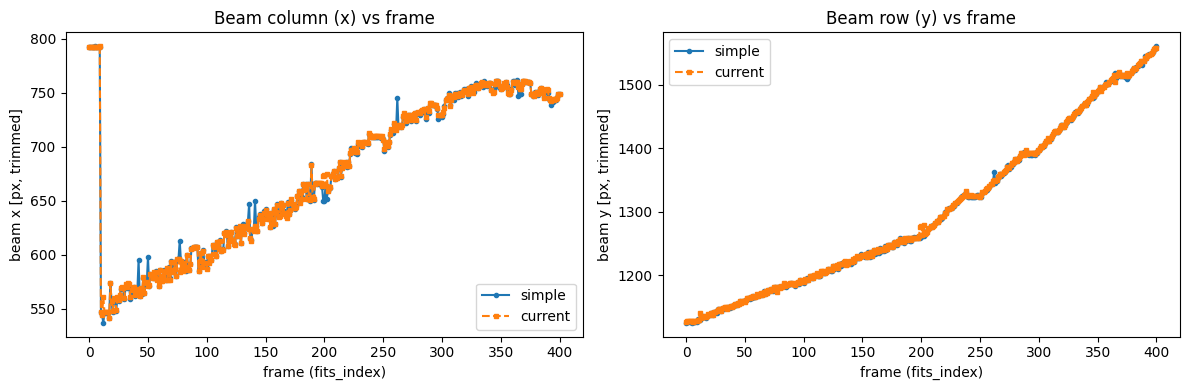

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, coord in zip(axes, ["x", "y"]):
    ax.plot(cmp["fits_index"], cmp[f"{coord}_simple"], "o-", ms=3, label="simple")
    ax.plot(cmp["fits_index"], cmp[f"{coord}_current"], "s--", ms=3, label="current")
    ax.set_xlabel("frame (fits_index)")
    ax.set_ylabel(f"beam {coord} [px, trimmed]")
    ax.legend()
axes[0].set_title("Beam column (x) vs frame")
axes[1].set_title("Beam row (y) vs frame")
fig.tight_layout()

## 7. Reflectivity: simple vs current

Overlays R vs q from each tracker (all energies/polarizations together).

C:\Users\TJFerron\Documents\Github\als-rsoxs\pxr-reduce\src\pxr_reduce\reduction.py:447: UserWarning: Scan starting at fits_index 0 only has one stitch point.
  df = _apply_per_scan(df, lambda g: compute_scale_factors(g, config))
C:\Users\TJFerron\Documents\Github\als-rsoxs\pxr-reduce\src\pxr_reduce\reduction.py:74: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(stitch_ratio_model, pre_r, post_r, p0=[1.0])
Stitch at theta 4.7383 (backstep+hos): 1 overlap point(s), scale=36.1 +/- 0.
Stitch at theta 9.7383 (backstep+hos): 3 overlap point(s), scale=13.47 +/- 0.55.
Stitch at theta 14.4083 (backstep+hos+exposure): 2 overlap point(s), scale=3.259 +/- 0.15.
Stitch at theta 19.3932 (backstep+exposure): 2 overlap point(s), scale=1.791 +/- 0.31.
Stitch at theta 29.3691 (backstep+exposure): 3 overlap point(s), scale=1.22 +/- 0.14.
C:\Users\TJFerron\Documents\Github\als-rsoxs\pxr-reduce\src\pxr_reduce\reduction.py:447: UserWarning: Scan starting at fi

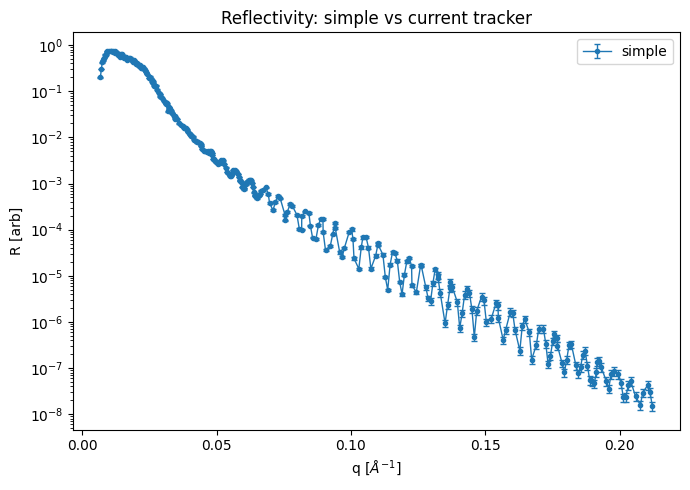

In [10]:
r_simple = simple.reduce()
r_current = current.reduce()

fig, ax = plt.subplots(figsize=(7, 5))
for label, r, style in [("simple", r_simple, "o-")]:#, ("current", r_current, "s--")]:
    r = r.sort_values("q")
    ax.errorbar(r["q"], r["R"], yerr=r["R_err"], fmt=style, ms=3, lw=1,
                capsize=2, label=label)
ax.set_yscale("log")
ax.set_xlabel(r"q [$\AA^{-1}$]")
ax.set_ylabel("R [arb]")
ax.set_title("Reflectivity: simple vs current tracker")
ax.legend()
fig.tight_layout()

## 8. Inspect a single frame

Set `INSPECT_INDEX` to any `fits_index` (e.g. one flagged in section 5) to see
where each tracker placed the beam. Red **x** = simple, blue **+** = current.

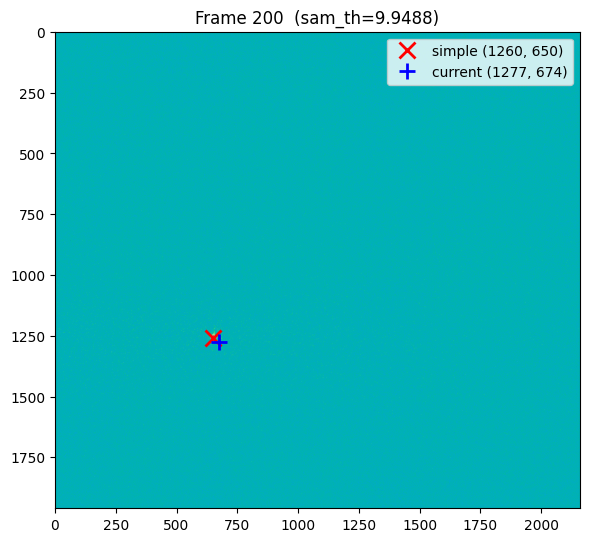

In [9]:
from matplotlib.colors import LogNorm

INSPECT_INDEX = int(simple.data["fits_index"].iloc[len(simple.data) // 2])

img = simple.get_clean_image(INSPECT_INDEX)  # trimmed+cleaned; same for both
row_s = simple.data.loc[simple.data["fits_index"] == INSPECT_INDEX]
row_c = current.data.loc[current.data["fits_index"] == INSPECT_INDEX]
bs_s = row_s["beam_spot"].iloc[0]
bs_c = row_c["beam_spot"].iloc[0]

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(np.clip(img, 1, None), norm=LogNorm(), cmap="terrain")
ax.plot(bs_s[1], bs_s[0], "rx", ms=12, mew=2, label=f"simple {tuple(bs_s)}")
ax.plot(bs_c[1], bs_c[0], "b+", ms=12, mew=2, label=f"current {tuple(bs_c)}")
ax.set_title(f"Frame {INSPECT_INDEX}  (sam_th={row_s['sam_th'].iloc[0]:.4f})")
ax.legend()
fig.tight_layout()

## 9. Stitch diagnostics

One row per detected stitch boundary: what **triggered** it (back-step and/or
which condition changed), the **conditions_changed** before→after values, how
many **overlap points** were used, and the fitted **scale**. A boundary with
`num_stitch_points == 0` or `failed == True` is a stitch that isn't working.
An empty table means no boundaries were detected — check that a condition
(hos/exposure/slits) actually changes and that `sam_th` steps back.

In [13]:
# Uses whichever loader you processed above (the simple tracker here).
simple.diagnose_stitches()

C:\Users\TJFerron\Documents\Github\als-rsoxs\pxr-reduce\src\pxr_reduce\reduction.py:478: UserWarning: Scan starting at fits_index 0 only has one stitch point.
  scaled = _apply_per_scan(marked, lambda g: compute_scale_factors(g, config))
C:\Users\TJFerron\Documents\Github\als-rsoxs\pxr-reduce\src\pxr_reduce\reduction.py:74: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(stitch_ratio_model, pre_r, post_r, p0=[1.0])
Stitch at theta 4.7383 (backstep+hos): 1 overlap point(s), scale=36.1 +/- 0.
Stitch at theta 9.7383 (backstep+hos): 3 overlap point(s), scale=13.47 +/- 0.55.
Stitch at theta 14.4083 (backstep+hos+exposure): 2 overlap point(s), scale=3.259 +/- 0.15.
Stitch at theta 19.3932 (backstep+exposure): 2 overlap point(s), scale=1.791 +/- 0.31.
Stitch at theta 29.3691 (backstep+exposure): 3 overlap point(s), scale=1.22 +/- 0.14.


,scan,fits_index,sam_th,energy,polarization,trigger,conditions_changed,num_stitch_points,scale,scale_err,failed
0,0,86,4.7383,380.0,100.0,backstep+hos,hos: 9.5->8.5,1,36.095641,0.000000,False
1,0,192,9.7383,380.0,100.0,backstep+hos,hos: 8.5->7,3,486.386694,19.690186,False
2,0,239,14.4083,380.0,100.0,backstep+hos+exposure,"hos: 7->6, exposure: 0.00789278->0.0138928",2,1585.012281,97.746143,False
3,0,290,19.3932,380.0,100.0,backstep+exposure,exposure: 0.0138928->0.103893,2,2838.060184,517.674832,False
4,0,369,29.3691,380.0,100.0,backstep+exposure,exposure: 0.103893->0.503893,3,3463.141244,750.817639,False


## 10. (Optional) Save the simple-tracker result

Writes a clean, rounded `.dat` + plots (uses the export you already have).

In [ ]:
from pxr_reduce.dataset import ReducedDataset

# ReducedDataset.from_loader(simple).save("results/simple_tracked.dat")